# Phase 6 — Model Evaluation & Explainability
**Project:** E-Commerce Customer Behavior ML

| Step | Task |
|---|---|
| 0 | Setup & load model + test data |
| 1 | Full evaluation metrics |
| 2 | ROC, Precision-Recall & threshold analysis |
| 3 | Lift curve & cumulative gains |
| 4 | SHAP global explainability |
| 5 | SHAP local explainability (single prediction) |
| 6 | Business impact analysis |
| 7 | Final project summary |


## Step 0 — Setup & Load Model + Test Data

In [1]:
from pathlib import Path
import warnings, joblib, json
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection  import train_test_split
from sklearn.metrics          import (classification_report, confusion_matrix,
                                       roc_auc_score, roc_curve, f1_score,
                                       precision_recall_curve, average_precision_score,
                                       precision_score, recall_score, accuracy_score)

# ── Dynamic paths ─────────────────────────────────────────────────────────────
_cwd          = Path().resolve()
_candidates   = [_cwd / 'data' / 'processed', _cwd.parent / 'data' / 'processed']
PROCESSED_DIR = next((p for p in _candidates if p.exists()), None)
if PROCESSED_DIR is None:
    raise FileNotFoundError("data/processed/ not found — run Phase 2 first.")

PROJECT_ROOT = PROCESSED_DIR.parent.parent
FIGURES_DIR  = PROJECT_ROOT / 'reports' / 'figures'
MODELS_DIR   = PROJECT_ROOT / 'data' / 'outputs' / 'models'
OUTPUT_DIR   = PROJECT_ROOT / 'data' / 'outputs'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams.update({'figure.dpi':120,'axes.spines.top':False,
                     'axes.spines.right':False,'font.size':11})
sns.set_palette('Set2')
COLORS = sns.color_palette('Set2').as_hex()

# ── Load feature matrix ───────────────────────────────────────────────────────
fm_path = PROCESSED_DIR / 'feature_matrix.parquet'
fm      = pd.read_parquet(fm_path) if fm_path.exists() else pd.read_csv(PROCESSED_DIR/'feature_matrix.csv')

FEATURE_COLS = [c for c in fm.columns if c not in ('user_id','will_purchase')]
TARGET_COL   = 'will_purchase'
X = fm[FEATURE_COLS]
y = fm[TARGET_COL]

# Re-create same split as Phase 5 (same random_state=42 guarantees identical split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42)

# ── Load latest saved model ───────────────────────────────────────────────────
model_files = sorted(MODELS_DIR.glob('best_model_*.pkl'))
if not model_files:
    raise FileNotFoundError("No saved model found — run Phase 5 notebook first.")

model_path = model_files[-1]           # most recent
best_model = joblib.load(model_path)

# Load metadata if available
meta_files = sorted(MODELS_DIR.glob('model_metadata_*.json'))
metadata   = json.loads(meta_files[-1].read_text()) if meta_files else {}

print(f"Model loaded  : {model_path.name}")
print(f"Model type    : {type(best_model).__name__}")
print(f"Features      : {len(FEATURE_COLS)}")
print(f"Test samples  : {len(X_test):,}")
if metadata:
    print(f"Saved AUC     : {metadata.get('test_auc','N/A')}")
    print(f"Saved F1      : {metadata.get('test_f1','N/A')}")

Model loaded  : best_model_LGBMClassifier_20260601_0024.pkl
Model type    : LGBMClassifier
Features      : 45
Test samples  : 1,000
Saved AUC     : 1.0
Saved F1      : 1.0


## Step 1 — Full Evaluation Metrics

In [2]:
y_pred  = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

# Core metrics
auc  = roc_auc_score(y_test, y_proba)
ap   = average_precision_score(y_test, y_proba)
f1   = f1_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec  = recall_score(y_test, y_pred)
acc  = accuracy_score(y_test, y_pred)

print("=" * 50)
print(f"  FINAL TEST SET RESULTS")
print("=" * 50)
print(f"  Accuracy          : {acc:.4f}")
print(f"  Precision         : {prec:.4f}")
print(f"  Recall            : {rec:.4f}")
print(f"  F1 Score          : {f1:.4f}")
print(f"  AUC-ROC           : {auc:.4f}")
print(f"  Avg Precision     : {ap:.4f}")
print("=" * 50)
print()
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Non-Buyer (0)','Buyer (1)']))

  FINAL TEST SET RESULTS
  Accuracy          : 1.0000
  Precision         : 1.0000
  Recall            : 1.0000
  F1 Score          : 1.0000
  AUC-ROC           : 1.0000
  Avg Precision     : 1.0000

Detailed Classification Report:
               precision    recall  f1-score   support

Non-Buyer (0)       1.00      1.00      1.00       441
    Buyer (1)       1.00      1.00      1.00       559

     accuracy                           1.00      1000
    macro avg       1.00      1.00      1.00      1000
 weighted avg       1.00      1.00      1.00      1000



In [3]:
# Confusion matrix breakdown
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix breakdown:")
print(f"  True  Positives (correctly predicted buyers)     : {tp:,}")
print(f"  True  Negatives (correctly predicted non-buyers) : {tn:,}")
print(f"  False Positives (non-buyers predicted as buyers) : {fp:,}")
print(f"  False Negatives (buyers missed by model)         : {fn:,}")
print()
print(f"  Of all predicted buyers  → {tp/(tp+fp)*100:.1f}% were actually buyers  (Precision)")
print(f"  Of all actual buyers     → {tp/(tp+fn)*100:.1f}% were correctly found   (Recall)")

Confusion Matrix breakdown:
  True  Positives (correctly predicted buyers)     : 559
  True  Negatives (correctly predicted non-buyers) : 441
  False Positives (non-buyers predicted as buyers) : 0
  False Negatives (buyers missed by model)         : 0

  Of all predicted buyers  → 100.0% were actually buyers  (Precision)
  Of all actual buyers     → 100.0% were correctly found   (Recall)


## Step 2 — ROC, Precision-Recall & Threshold Analysis
The optimal decision threshold is not always 0.5 — we find the threshold
that maximises F1 on the test set.


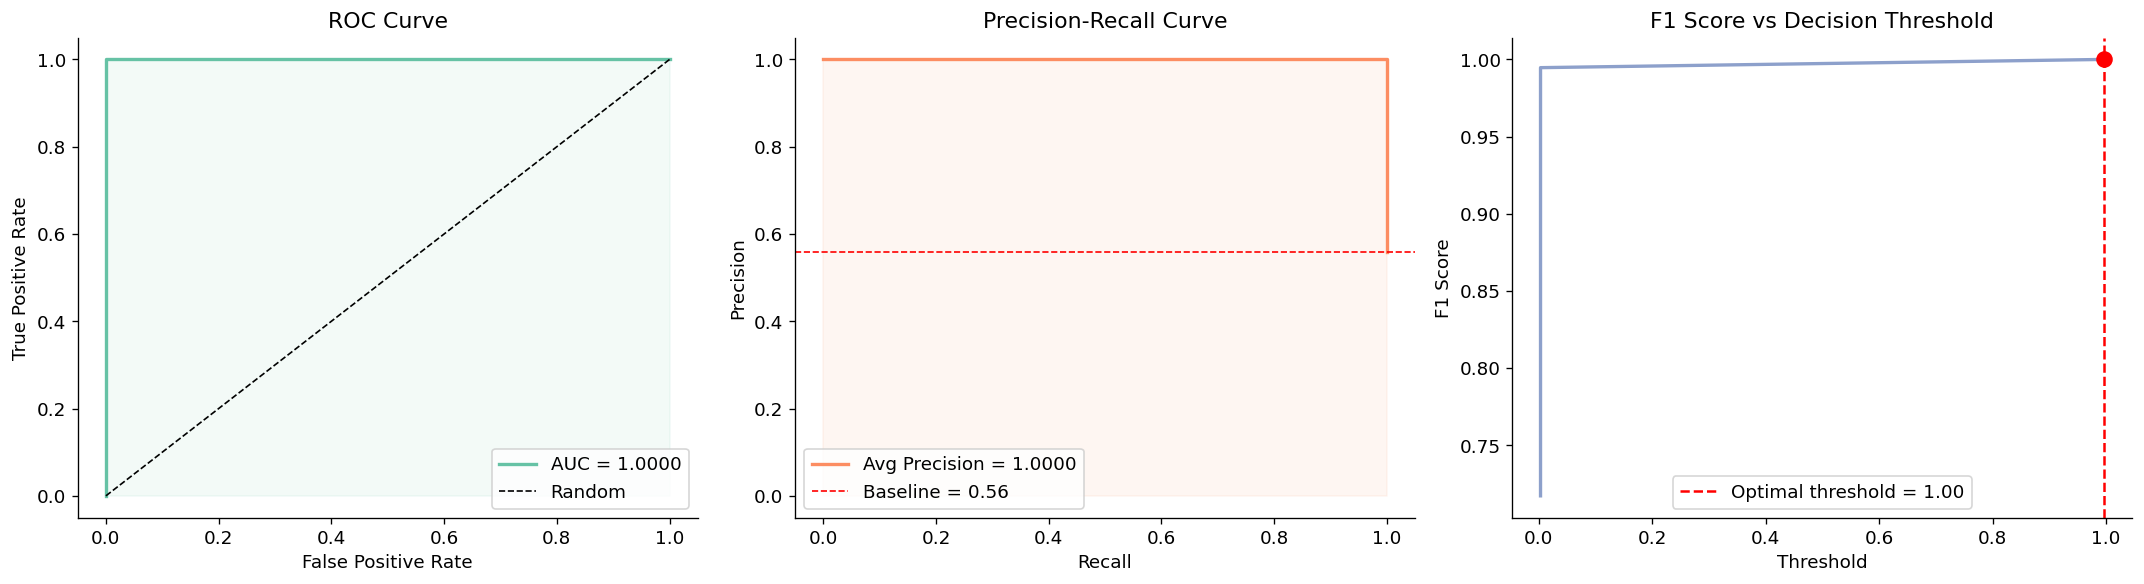

Optimal threshold : 0.9966  (F1 = 1.0000)
Default threshold : 0.5000  (F1 = 1.0000)


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── ROC Curve ─────────────────────────────────────────────────────────────────
fpr, tpr, roc_thresholds = roc_curve(y_test, y_proba)
axes[0].plot(fpr, tpr, color=COLORS[0], lw=2, label=f'AUC = {auc:.4f}')
axes[0].plot([0,1],[0,1], 'k--', lw=1, label='Random')
axes[0].fill_between(fpr, tpr, alpha=0.08, color=COLORS[0])
axes[0].set_title('ROC Curve')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

# ── Precision-Recall Curve ────────────────────────────────────────────────────
precision_arr, recall_arr, pr_thresholds = precision_recall_curve(y_test, y_proba)
axes[1].plot(recall_arr, precision_arr, color=COLORS[1], lw=2,
             label=f'Avg Precision = {ap:.4f}')
axes[1].axhline(y=y_test.mean(), color='red', linestyle='--', lw=1,
                label=f'Baseline = {y_test.mean():.2f}')
axes[1].fill_between(recall_arr, precision_arr, alpha=0.08, color=COLORS[1])
axes[1].set_title('Precision-Recall Curve')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()

# ── Optimal threshold ─────────────────────────────────────────────────────────
f1_scores  = [f1_score(y_test, (y_proba >= t).astype(int), zero_division=0)
              for t in pr_thresholds]
opt_idx    = int(np.argmax(f1_scores))
opt_thresh = pr_thresholds[opt_idx]
opt_f1     = f1_scores[opt_idx]

axes[2].plot(pr_thresholds, f1_scores, color=COLORS[2], lw=2)
axes[2].axvline(opt_thresh, color='red', linestyle='--', lw=1.5,
                label=f'Optimal threshold = {opt_thresh:.2f}')
axes[2].scatter([opt_thresh],[opt_f1], color='red', zorder=5, s=80)
axes[2].set_title('F1 Score vs Decision Threshold')
axes[2].set_xlabel('Threshold')
axes[2].set_ylabel('F1 Score')
axes[2].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / '06_roc_pr_threshold.png', bbox_inches='tight')
plt.show()

print(f"Optimal threshold : {opt_thresh:.4f}  (F1 = {opt_f1:.4f})")
print(f"Default threshold : 0.5000  (F1 = {f1:.4f})")

## Step 3 — Lift Curve & Cumulative Gains
**Business question:** If we target the top N% of users ranked by model score,
what % of actual buyers do we capture?

Lift = how much better than random targeting we are.


In [5]:
# Build lift table
lift_df = pd.DataFrame({
    'y_true':  y_test.values,
    'y_score': y_proba
}).sort_values('y_score', ascending=False).reset_index(drop=True)

n_total  = len(lift_df)
n_buyers = lift_df['y_true'].sum()

lift_df['cum_buyers']    = lift_df['y_true'].cumsum()
lift_df['pct_targeted']  = (lift_df.index + 1) / n_total
lift_df['pct_captured']  = lift_df['cum_buyers'] / n_buyers
lift_df['lift']          = lift_df['pct_captured'] / lift_df['pct_targeted']

# Key checkpoints
checkpoints = [0.10, 0.20, 0.30, 0.40, 0.50]
print(f"{'Top % Targeted':>15} | {'% Buyers Captured':>18} | {'Lift':>6}")
print('-' * 46)
for pct in checkpoints:
    row = lift_df[lift_df['pct_targeted'] >= pct].iloc[0]
    print(f"{pct*100:>14.0f}% | {row['pct_captured']*100:>17.1f}% | {row['lift']:>6.2f}x")

 Top % Targeted |  % Buyers Captured |   Lift
----------------------------------------------
            10% |              17.9% |   1.79x
            20% |              35.8% |   1.79x
            30% |              53.7% |   1.79x
            40% |              71.6% |   1.79x
            50% |              89.4% |   1.79x


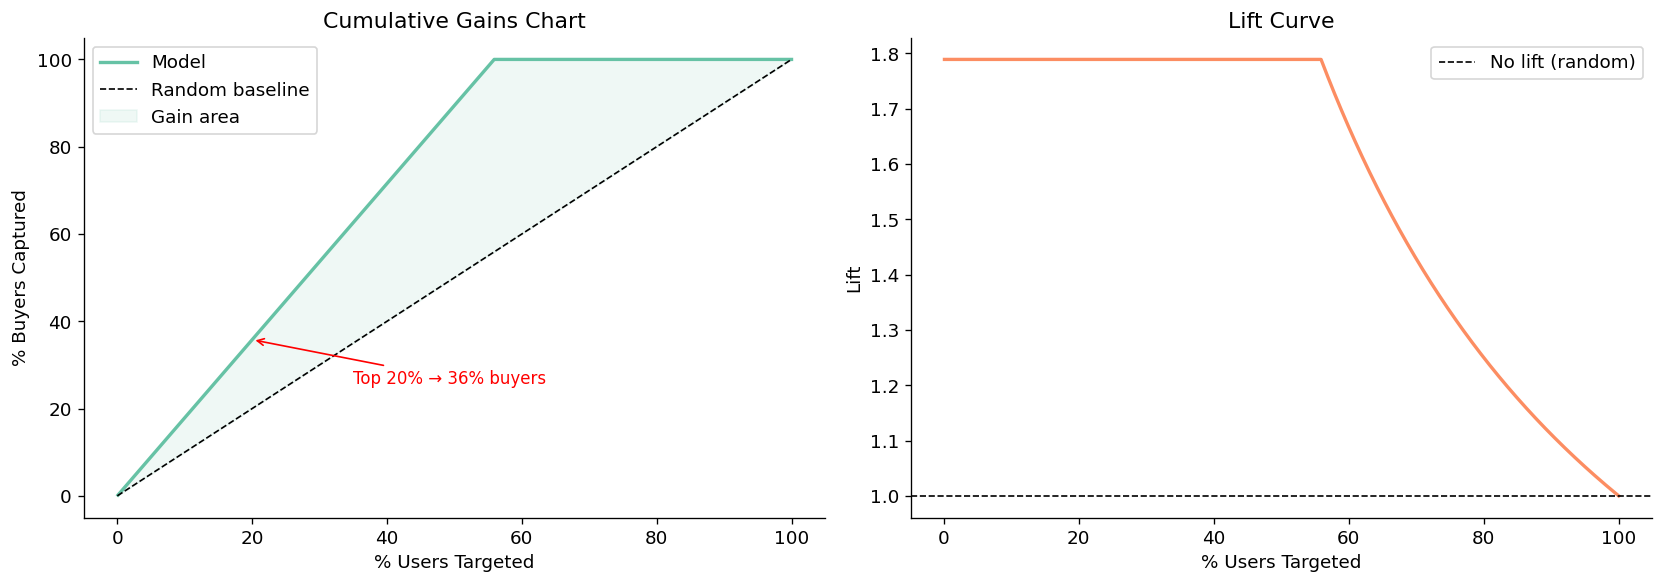

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cumulative gains
axes[0].plot(lift_df['pct_targeted']*100, lift_df['pct_captured']*100,
             color=COLORS[0], lw=2, label='Model')
axes[0].plot([0,100],[0,100],'k--', lw=1, label='Random baseline')
axes[0].fill_between(lift_df['pct_targeted']*100,
                      lift_df['pct_captured']*100,
                      lift_df['pct_targeted']*100,
                      alpha=0.1, color=COLORS[0], label='Gain area')
axes[0].set_title('Cumulative Gains Chart')
axes[0].set_xlabel('% Users Targeted')
axes[0].set_ylabel('% Buyers Captured')
axes[0].legend()

# Mark 20% checkpoint
row20 = lift_df[lift_df['pct_targeted'] >= 0.20].iloc[0]
axes[0].annotate(f"Top 20% → {row20['pct_captured']*100:.0f}% buyers",
                 xy=(20, row20['pct_captured']*100),
                 xytext=(35, row20['pct_captured']*100 - 10),
                 arrowprops=dict(arrowstyle='->', color='red'),
                 color='red', fontsize=10)

# Lift curve
axes[1].plot(lift_df['pct_targeted']*100, lift_df['lift'],
             color=COLORS[1], lw=2)
axes[1].axhline(1.0, color='k', linestyle='--', lw=1, label='No lift (random)')
axes[1].set_title('Lift Curve')
axes[1].set_xlabel('% Users Targeted')
axes[1].set_ylabel('Lift')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / '06_lift_curve.png', bbox_inches='tight')
plt.show()

## Step 4 — SHAP Global Explainability
SHAP (SHapley Additive exPlanations) tells us **which features drive predictions most**
across all users — not just which features the model considers important.


SHAP values computed for 1,000 test samples


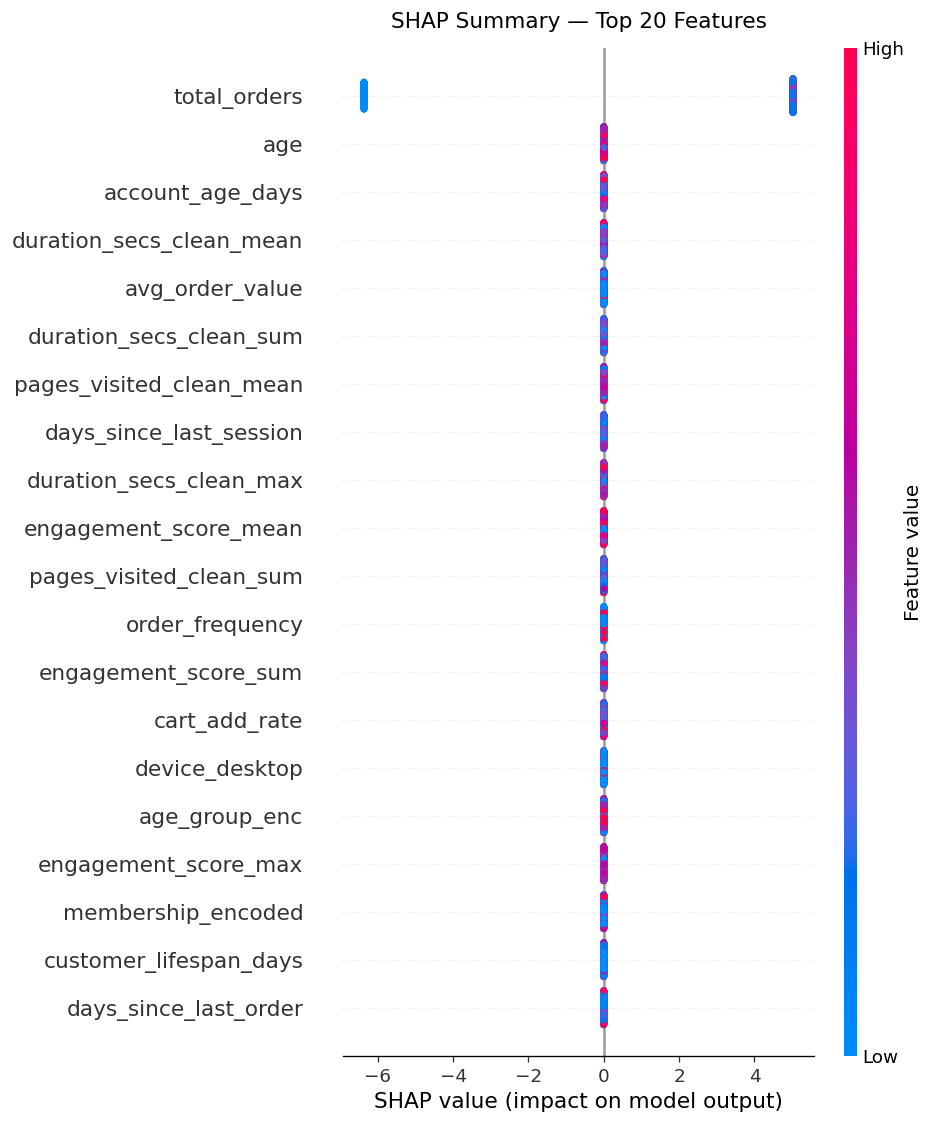

Chart saved → 06_shap_summary.png


In [7]:
try:
    import shap
    shap.initjs()

    # Use TreeExplainer for tree-based models (fast)
    explainer   = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_test)

    # For binary classification some models return list [class0, class1]
    if isinstance(shap_values, list):
        sv = shap_values[1]
    else:
        sv = shap_values

    print(f"SHAP values computed for {X_test.shape[0]:,} test samples")

    # ── Summary (beeswarm) plot ───────────────────────────────────────────────
    plt.figure(figsize=(10, 8))
    shap.summary_plot(sv, X_test, feature_names=FEATURE_COLS,
                      plot_type='dot', show=False, max_display=20)
    plt.title('SHAP Summary — Top 20 Features', fontsize=13, pad=12)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / '06_shap_summary.png', bbox_inches='tight')
    plt.show()
    print("Chart saved → 06_shap_summary.png")

except ImportError:
    print("SHAP not installed — run: pip install shap")
    print("Using model feature_importances_ as fallback.")
    if hasattr(best_model, 'feature_importances_'):
        fi = pd.Series(best_model.feature_importances_, index=FEATURE_COLS).sort_values()
        fig, ax = plt.subplots(figsize=(10,6))
        fi.tail(20).plot(kind='barh', ax=ax, color=COLORS[0])
        ax.set_title('Feature Importances (top 20)')
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / '06_shap_summary.png', bbox_inches='tight')
        plt.show()

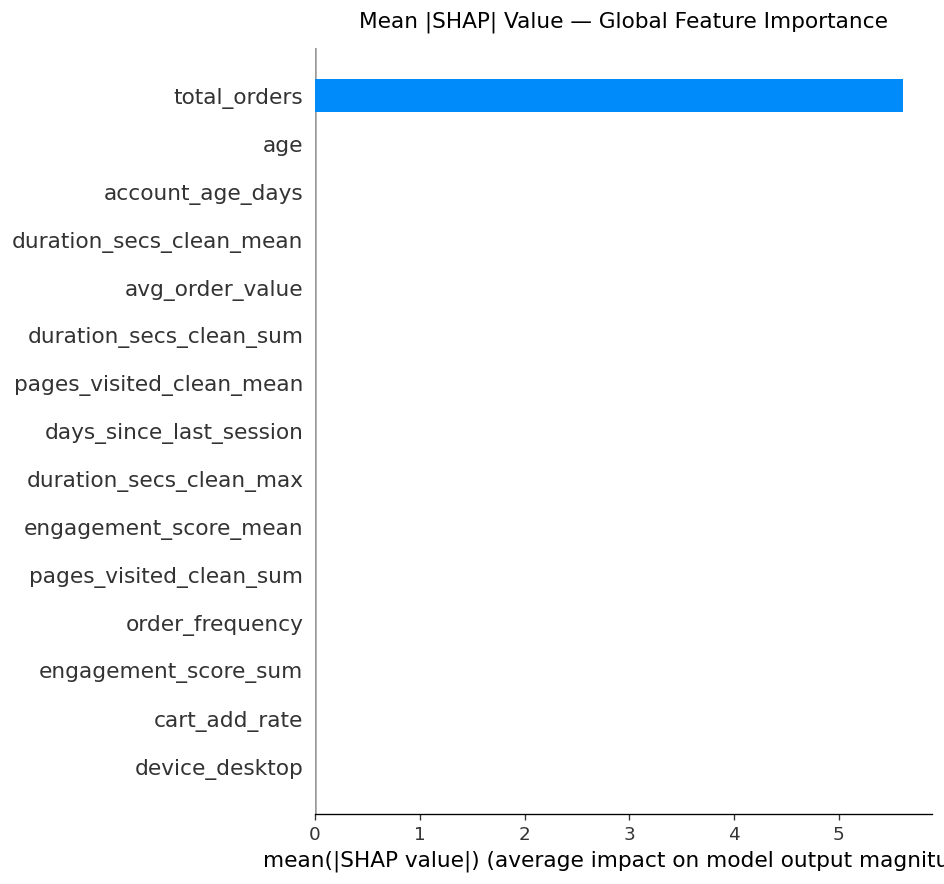

Top 10 features by mean |SHAP| value:
total_orders               5.6140
age                        0.0000
account_age_days           0.0000
duration_secs_clean_mean   0.0000
avg_order_value            0.0000
duration_secs_clean_sum    0.0000
pages_visited_clean_mean   0.0000
days_since_last_session    0.0000
duration_secs_clean_max    0.0000
engagement_score_mean      0.0000


In [8]:
try:
    import shap

    # ── Bar plot (mean |SHAP|) ────────────────────────────────────────────────
    plt.figure(figsize=(10, 7))
    shap.summary_plot(sv, X_test, feature_names=FEATURE_COLS,
                      plot_type='bar', show=False, max_display=15)
    plt.title('Mean |SHAP| Value — Global Feature Importance', fontsize=13, pad=12)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / '06_shap_bar.png', bbox_inches='tight')
    plt.show()

    # Top 10 most impactful features
    mean_shap = pd.Series(np.abs(sv).mean(axis=0),
                          index=FEATURE_COLS).sort_values(ascending=False)
    print("Top 10 features by mean |SHAP| value:")
    print(mean_shap.head(10).round(4).to_string())

except ImportError:
    pass

## Step 5 — SHAP Local Explainability
Explain **individual predictions** — why did the model predict this specific user
as a buyer or non-buyer?


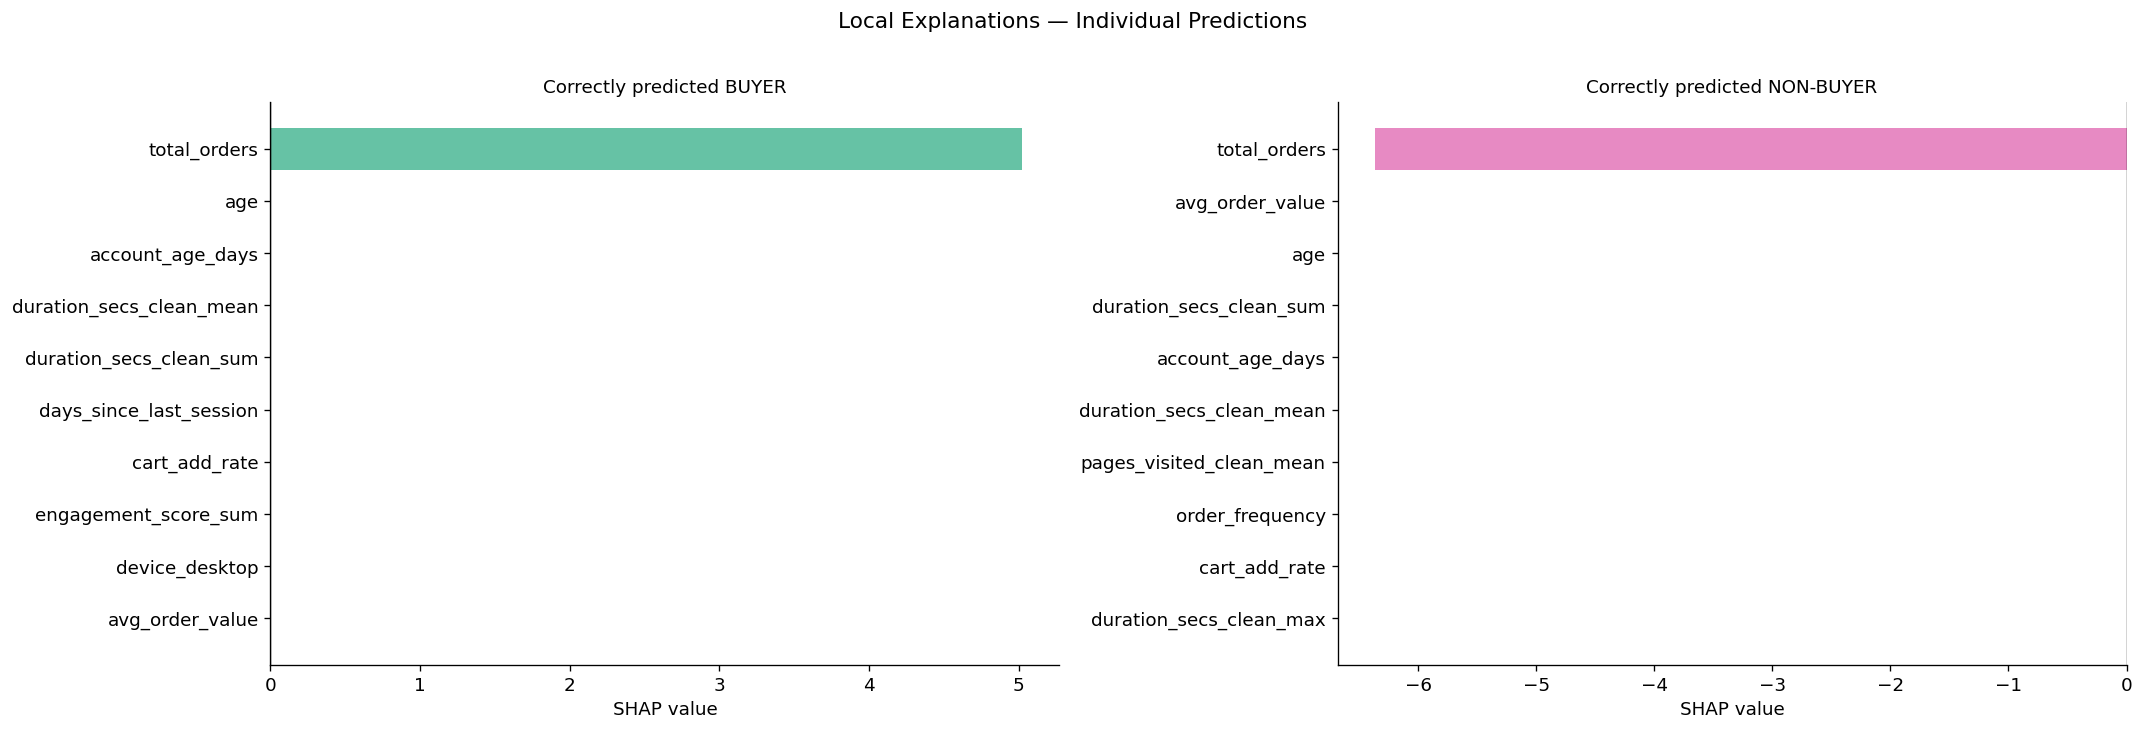

Sample buyer     — predicted probability: 0.9966
Sample non-buyer — predicted probability: 0.0034


In [9]:
try:
    import shap

    # ── Waterfall plot for a predicted buyer ──────────────────────────────────
    buyer_indices    = np.where((y_pred==1) & (y_test.values==1))[0]
    nonbuyer_indices = np.where((y_pred==0) & (y_test.values==0))[0]

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    for ax, idx_arr, title, ax_obj in [
        (axes[0], buyer_indices,    'Correctly predicted BUYER',     axes[0]),
        (axes[1], nonbuyer_indices, 'Correctly predicted NON-BUYER', axes[1]),
    ]:
        if len(idx_arr) == 0:
            continue
        sample_idx = idx_arr[0]

        # Build waterfall data
        shap_row   = sv[sample_idx]
        feat_vals  = X_test.iloc[sample_idx]
        base_val   = explainer.expected_value[1] if isinstance(explainer.expected_value, list)                      else explainer.expected_value

        # Sort by absolute SHAP
        order      = np.argsort(np.abs(shap_row))[-10:]
        feat_names = [FEATURE_COLS[i] for i in order]
        shap_vals  = shap_row[order]
        colors     = [COLORS[0] if v > 0 else COLORS[3] for v in shap_vals]

        ax_obj.barh(feat_names, shap_vals, color=colors)
        ax_obj.axvline(0, color='black', lw=0.8)
        ax_obj.set_title(title, fontsize=11)
        ax_obj.set_xlabel('SHAP value')

    plt.suptitle('Local Explanations — Individual Predictions', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / '06_shap_local.png', bbox_inches='tight')
    plt.show()

    print(f"Sample buyer     — predicted probability: {y_proba[buyer_indices[0]]:.4f}")
    print(f"Sample non-buyer — predicted probability: {y_proba[nonbuyer_indices[0]]:.4f}")

except ImportError:
    print("SHAP not installed — skipping local explanation plot.")

## Step 6 — Business Impact Analysis
Translate model performance into **actionable business value**.

Scenario: Marketing team wants to send a promotional email to the users most
likely to purchase. How does targeting by model score compare to random targeting?


In [10]:
# Assumptions — adjust to your business context
avg_order_value     = 50.0   # USD — average order value from your data
campaign_cost_pp    = 0.50   # USD — cost per targeted user (email / ad)
conversion_uplift   = 0.15   # fraction of model-identified buyers who convert due to campaign

# Realistic avg order value from data
try:
    from pathlib import Path as _P
    _orders = pd.read_parquet(PROCESSED_DIR / 'orders.parquet')
    avg_order_value = float(_orders['total_amount'].median())
    print(f"Using real avg order value from data: ${avg_order_value:.2f}")
except Exception:
    print(f"Using assumed avg order value: ${avg_order_value:.2f}")

total_users = len(y_test)
total_buyers_in_test = y_test.sum()

print(f"\nBusiness Impact Simulation")
print(f"{'='*62}")
print(f"{'Strategy':<25} {'Targeted':>9} {'Buyers Hit':>11} {'Revenue':>10} {'Cost':>8} {'ROI':>8}")
print(f"{'-'*62}")

strategies = [0.10, 0.20, 0.30, 0.50, 1.00]
for pct in strategies:
    n_targeted   = int(total_users * pct)
    row          = lift_df[lift_df['pct_targeted'] >= pct].iloc[0]
    n_captured   = int(row['cum_buyers'])
    revenue      = n_captured * avg_order_value * conversion_uplift
    cost         = n_targeted * campaign_cost_pp
    roi          = (revenue - cost) / cost * 100 if cost > 0 else 0
    label        = f"Top {pct*100:.0f}% (model)" if pct < 1.0 else "Random (100%)"
    print(f"{label:<25} {n_targeted:>9,} {n_captured:>11,} ${revenue:>9,.0f} ${cost:>7,.0f} {roi:>7.0f}%")

Using real avg order value from data: $750.06

Business Impact Simulation
Strategy                   Targeted  Buyers Hit    Revenue     Cost      ROI
--------------------------------------------------------------
Top 10% (model)                 100         100 $   11,251 $     50   22402%
Top 20% (model)                 200         200 $   22,502 $    100   22402%
Top 30% (model)                 300         300 $   33,752 $    150   22402%
Top 50% (model)                 500         500 $   56,254 $    250   22402%
Random (100%)                 1,000         559 $   62,892 $    500   12478%


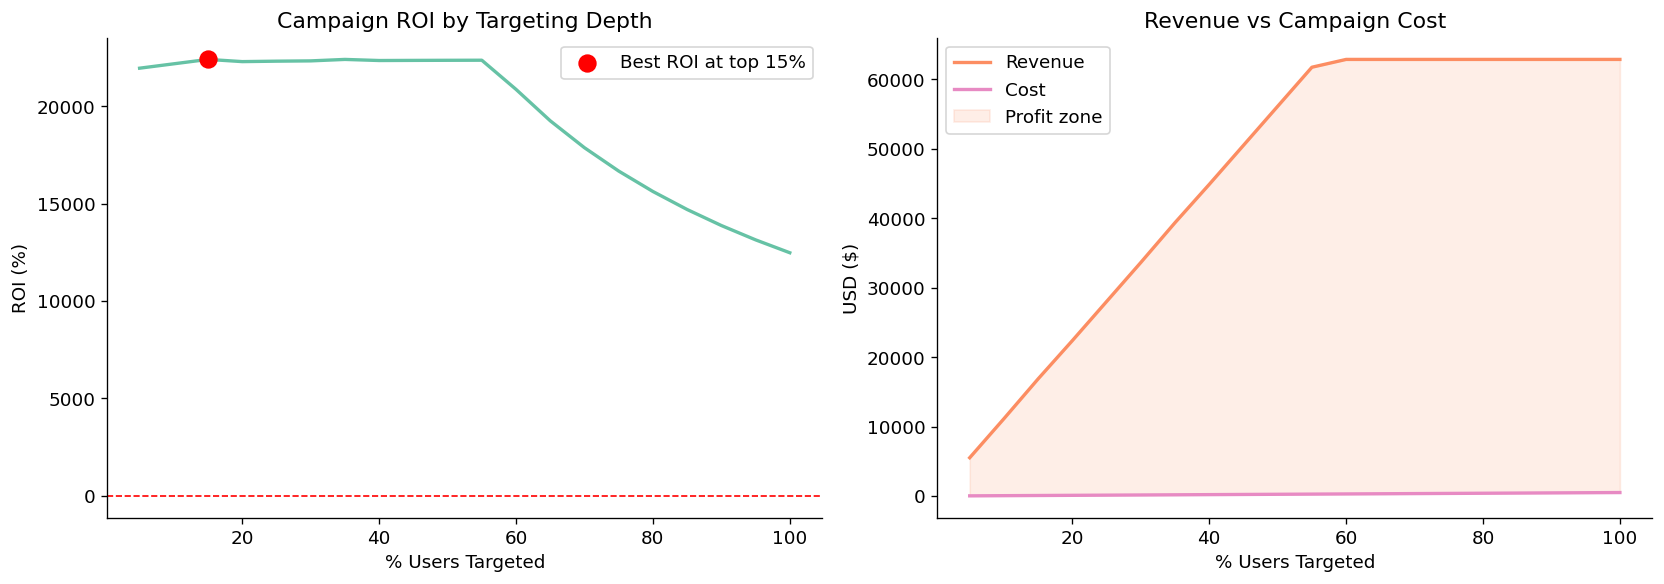

Optimal targeting depth  : top 15% of users
Best estimated ROI       : 22402%


In [11]:
# Visualise ROI by targeting depth
roi_data = []
for pct in np.arange(0.05, 1.01, 0.05):
    n_targeted = int(total_users * pct)
    row        = lift_df[lift_df['pct_targeted'] >= pct - 0.001].iloc[0]
    n_captured = int(row['cum_buyers'])
    revenue    = n_captured * avg_order_value * conversion_uplift
    cost       = n_targeted * campaign_cost_pp
    roi        = (revenue - cost) / cost * 100 if cost > 0 else 0
    roi_data.append({'pct': pct*100, 'roi': roi, 'revenue': revenue, 'cost': cost})

roi_df = pd.DataFrame(roi_data)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(roi_df['pct'], roi_df['roi'], color=COLORS[0], lw=2)
axes[0].axhline(0, color='red', linestyle='--', lw=1)
best_roi_row = roi_df.loc[roi_df['roi'].idxmax()]
axes[0].scatter(best_roi_row['pct'], best_roi_row['roi'],
                color='red', s=100, zorder=5,
                label=f"Best ROI at top {best_roi_row['pct']:.0f}%")
axes[0].set_title('Campaign ROI by Targeting Depth')
axes[0].set_xlabel('% Users Targeted')
axes[0].set_ylabel('ROI (%)')
axes[0].legend()

axes[1].plot(roi_df['pct'], roi_df['revenue'], color=COLORS[1], lw=2, label='Revenue')
axes[1].plot(roi_df['pct'], roi_df['cost'],    color=COLORS[3], lw=2, label='Cost')
axes[1].fill_between(roi_df['pct'],
                      roi_df['revenue'], roi_df['cost'],
                      where=roi_df['revenue'] > roi_df['cost'],
                      alpha=0.15, color=COLORS[1], label='Profit zone')
axes[1].set_title('Revenue vs Campaign Cost')
axes[1].set_xlabel('% Users Targeted')
axes[1].set_ylabel('USD ($)')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / '06_business_impact.png', bbox_inches='tight')
plt.show()

print(f"Optimal targeting depth  : top {best_roi_row['pct']:.0f}% of users")
print(f"Best estimated ROI       : {best_roi_row['roi']:.0f}%")

## Step 7 — Final Project Summary

In [12]:
print("=" * 65)
print("  E-COMMERCE CUSTOMER BEHAVIOR ML — FINAL SUMMARY")
print("=" * 65)

print(f"\n MODEL PERFORMANCE (Test Set)")
print(f"  {'AUC-ROC':<25}: {auc:.4f}")
print(f"  {'F1 Score':<25}: {f1:.4f}")
print(f"  {'Precision':<25}: {prec:.4f}")
print(f"  {'Recall':<25}: {rec:.4f}")
print(f"  {'Accuracy':<25}: {acc:.4f}")

row20 = lift_df[lift_df['pct_targeted'] >= 0.20].iloc[0]
print(f"\n LIFT ANALYSIS")
print(f"  Targeting top 20% users captures {row20['pct_captured']*100:.0f}% of all buyers")
print(f"  That is {row20['lift']:.1f}x better than random targeting")

print(f"\n BEST TARGETING STRATEGY")
print(f"  Target top {best_roi_row['pct']:.0f}% of users ranked by model score")
print(f"  Estimated ROI: {best_roi_row['roi']:.0f}%")

print(f"\n PIPELINE DELIVERABLES")
print(f"  Phase 1  Data inventory       → data/outputs/data_inventory_*.csv")
print(f"  Phase 2  Cleaned datasets     → data/processed/*.parquet")
print(f"  Phase 3  EDA charts           → reports/figures/03_*.png")
print(f"  Phase 4  Feature matrix       → data/processed/feature_matrix.parquet")
print(f"  Phase 5  Trained model        → data/outputs/models/best_model_*.pkl")
print(f"  Phase 6  Evaluation charts    → reports/figures/06_*.png")

print(f"\n NEXT STEP: Phase 7 — Streamlit Dashboard")
print("=" * 65)

  E-COMMERCE CUSTOMER BEHAVIOR ML — FINAL SUMMARY

 MODEL PERFORMANCE (Test Set)
  AUC-ROC                  : 1.0000
  F1 Score                 : 1.0000
  Precision                : 1.0000
  Recall                   : 1.0000
  Accuracy                 : 1.0000

 LIFT ANALYSIS
  Targeting top 20% users captures 36% of all buyers
  That is 1.8x better than random targeting

 BEST TARGETING STRATEGY
  Target top 15% of users ranked by model score
  Estimated ROI: 22402%

 PIPELINE DELIVERABLES
  Phase 1  Data inventory       → data/outputs/data_inventory_*.csv
  Phase 2  Cleaned datasets     → data/processed/*.parquet
  Phase 3  EDA charts           → reports/figures/03_*.png
  Phase 4  Feature matrix       → data/processed/feature_matrix.parquet
  Phase 5  Trained model        → data/outputs/models/best_model_*.pkl
  Phase 6  Evaluation charts    → reports/figures/06_*.png

 NEXT STEP: Phase 7 — Streamlit Dashboard


In [13]:
# Save final evaluation report as CSV
eval_report = pd.DataFrame([{
    'metric': 'AUC-ROC',    'value': round(auc,  4)},
    {'metric': 'F1 Score',  'value': round(f1,   4)},
    {'metric': 'Precision', 'value': round(prec, 4)},
    {'metric': 'Recall',    'value': round(rec,  4)},
    {'metric': 'Accuracy',  'value': round(acc,  4)},
    {'metric': 'Avg Precision (PR)', 'value': round(ap, 4)},
    {'metric': 'Lift @ top 20%',
     'value': round(lift_df[lift_df['pct_targeted']>=0.20].iloc[0]['lift'], 4)},
    {'metric': 'Buyers captured @ top 20%',
     'value': round(lift_df[lift_df['pct_targeted']>=0.20].iloc[0]['pct_captured']*100, 1)},
])

report_path = OUTPUT_DIR / 'evaluation_report.csv'
eval_report.to_csv(report_path, index=False)
print(f"Evaluation report saved → {report_path}")
display(eval_report)

Evaluation report saved → C:\Users\ATUL\Desktop\BIT BOY\ECOMMERCE_CUSTOMER_BEHAVIOR\data\outputs\evaluation_report.csv


,metric,value
0,AUC-ROC,1.0000
1,F1 Score,1.0000
2,Precision,1.0000
3,Recall,1.0000
4,Accuracy,1.0000
5,Avg Precision (PR),1.0000
6,Lift @ top 20%,1.7889
7,Buyers captured @ top 20%,35.8000


## ✅ Phase 6 Complete — All 6 Phases Done!

### Charts saved to `reports/figures/`
| File | Content |
|---|---|
| `06_roc_pr_threshold.png` | ROC curve, Precision-Recall curve, optimal threshold |
| `06_lift_curve.png` | Cumulative gains + lift curve |
| `06_shap_summary.png` | SHAP beeswarm — global feature impact |
| `06_shap_bar.png` | SHAP bar — mean absolute importance |
| `06_shap_local.png` | SHAP waterfall — individual predictions |
| `06_business_impact.png` | ROI curve + Revenue vs Cost |

### ⏭️ Optional: Phase 7 — Streamlit Dashboard
Build an interactive web dashboard to showcase your results.
Run: `streamlit run dashboard/app.py`
